In [195]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

#### Importing the dataset comprising data of children with illegal immigration status or no parent or guardian

In [196]:
df = pd.read_csv("HHS_Unaccompanied_Alien_Children_Program.csv")
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,21-Dec-25,6,18,11,"2,484",14
1,18-Dec-25,11,50,6,"2,472",16
2,17-Dec-25,7,31,11,"2,481",10
3,16-Dec-25,8,54,15,"2,468",9
4,15-Dec-25,11,42,9,"2,470",7


#### Checking for null values

In [197]:
df.isna().sum()

Date                                               0
Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64

#### Converting data to pandas date-time format

In [198]:
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2025-12-21,6,18,11,"2,484",14
1,2025-12-18,11,50,6,"2,472",16
2,2025-12-17,7,31,11,"2,481",10
3,2025-12-16,8,54,15,"2,468",9
4,2025-12-15,11,42,9,"2,470",7


#### Arrange dates in ascending order

In [199]:
df.sort_values(by=["Date"], inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-12,33,53,34,"6,566",436
1,2023-01-22,32,49,39,"7,122",227
2,2023-01-23,32,50,39,"7,280",181
3,2023-01-24,47,42,47,"7,433",175
4,2023-01-25,20,22,41,"7,538",180


#### Retrieving weekday names for each date in the dataset

In [200]:
df["Day of Week"] = list(map(lambda x: x.strftime("%A"), df["Date"]))
df = df[["Date","Day of Week","Children apprehended and placed in CBP custody*","Children in CBP custody","Children transferred out of CBP custody","Children in HHS Care","Children discharged from HHS Care"]]
df.head()

,Date,Day of Week,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-12,Thursday,33,53,34,"6,566",436
1,2023-01-22,Sunday,32,49,39,"7,122",227
2,2023-01-23,Monday,32,50,39,"7,280",181
3,2023-01-24,Tuesday,47,42,47,"7,433",175
4,2023-01-25,Wednesday,20,22,41,"7,538",180


#### Finding out the total number of records on each day of week

In [201]:
weekday_number = df["Day of Week"].value_counts().reset_index()
weekday_number["Day of Week Number"] = weekday_number["Day of Week"].map({
    "Sunday": "1",
    "Monday": "2",
    "Tuesday": "3",
    "Wednesday": "4",
    "Thursday": "5",
    "Friday": "6",
    "Saturday": "7"
})
weekday_number = weekday_number.sort_values(by=["Day of Week Number"]).reset_index(drop=True)
weekday_number

,Day of Week,count,Day of Week Number
0,Sunday,130,1
1,Monday,145,2
2,Tuesday,149,3
3,Wednesday,147,4
4,Thursday,147,5
5,Friday,2,6


Looking at the numbers above, we can see that the number of days on which children were recorded is relatively consistent from Sunday through Thursday. From Monday through Thursday, the figures range between 145 and 150 days. Sunday is somewhat lower, at 130 days, but it is still reasonably close to this range.

Friday, however, stands out as an exceptionally low number of recorded days. Data is recorded for only two Fridays, compared with more than 130 recorded days for each of the other weekdays. This substantial difference suggests that Friday may represent a distinct pattern in the data and warrants further investigation.

There is one assumption that we can make here, which is deleting those two Friday records and assuming that services are not provided on Fridays and Saturdays. But in reality, these services are provided 24 hours a day and 7 days a week. So we need to include these days on which data is not recorded and then somehow deal with the null values for number of children on these days.

#### Creating a new dataset with dates on which  data is not recorded

In [202]:
df_2 = pd.DataFrame(columns=df.columns)
df_2["Date"] = np.setdiff1d(pd.date_range(df["Date"].min(),df["Date"].max()).values,df["Date"].values)
df_2["Day of Week"] = list(map(lambda x: x.strftime("%A"), df_2["Date"]))
df_2[['Children apprehended and placed in CBP custody*','Children in CBP custody','Children transferred out of CBP custody','Children in HHS Care', 'Children discharged from HHS Care']] = np.nan
df_2.head()

,Date,Day of Week,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-13,Friday,NaN,NaN,NaN,NaN,NaN
1,2023-01-14,Saturday,NaN,NaN,NaN,NaN,NaN
2,2023-01-15,Sunday,NaN,NaN,NaN,NaN,NaN
3,2023-01-16,Monday,NaN,NaN,NaN,NaN,NaN
4,2023-01-17,Tuesday,NaN,NaN,NaN,NaN,NaN


#### Concatenating the original dataset with the new dataset comprising unrecorded dates

In [203]:
df_3 = pd.concat([df,df_2]).sort_values(by=["Date"]).reset_index(drop=True)
df_3.drop(columns=["Day of Week"], inplace=True)
df_3.set_index("Date", inplace=True)
df_3.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33.0,53.0,34.0,"6,566",436.0
2023-01-13,NaN,NaN,NaN,NaN,NaN
2023-01-14,NaN,NaN,NaN,NaN,NaN
2023-01-15,NaN,NaN,NaN,NaN,NaN
2023-01-16,NaN,NaN,NaN,NaN,NaN


#### Checking the data types of each feature

In [204]:
df_3.dtypes

Children apprehended and placed in CBP custody*    float64
Children in CBP custody                            float64
Children transferred out of CBP custody            float64
Children in HHS Care                                object
Children discharged from HHS Care                  float64
dtype: object

As we observe the above data types, the feature *Children in HHS care* is of object type. The other features are of float type. In reality, these features denote number of children going through their respective stage. This means that such features ought to be integers.

All the features except the *Children in HHS Care* are floating points, which makes it unnecessary for us to convert into integers, as they are of numeric type. The values for such features end with ".0". The *Children in HHS Care* is of object type, which is a non-numeric type - this forces us to convert it to numeric type. Before type conversion, let us see how the values of *Children in HHS Care* look like:

In [205]:
print(df_3["Children in HHS Care"].unique().tolist())

['6,566', nan, '7,122', '7,280', '7,433', '7,538', '7,472', '7,743', '7,803', '7,903', '7,879', '7,586', '7,720', '7,855', '7,915', '7,908', '7,434', '7,483', '7,794', '7,869', '7,793', '7,817', '7,967', '7,978', '7,914', '7,609', '7,800', '7,896', '7,930', '7,870', '7,859', '7,885', '7,786', '7,567', '7,810', '7,989', '7,931', '8,050', '8,097', '8,102', '7,847', '7,994', '8,079', '8,208', '8,158', '7,981', '8,054', '8,068', '8,175', '8,178', '7,900', '7,826', '7,922', '7,876', '7,795', '7,380', '7,344', '7,376', '7,356', '7,490', '7,534', '7,796', '8,017', '8,117', '8,159', '8,352', '8,492', '8,654', '8,704', '8,790', '8,485', '8,590', '8,606', '8,681', '8,672', '8,445', '8,571', '8,572', '8,569', '8,474', '7,848', '7,788', '7,709', '7,546', '6,996', '7,046', '7,053', '7,002', '6,555', '6,523', '6,508', '6,483', '6,446', '6,007', '6,021', '6,061', '6,065', '6,038', '5,679', '5,904', '5,922', '5,956', '5,766', '5,819', '5,917', '5,999', '6,058', '5,903', '6,127', '6,193', '6,239', '6,2

As we observe, there are commas in each element of *Children in HHS Care* column. We need to remove those columns and convert the data type into floating point so that the data type matches with that of other columns.

In [206]:
df_4.columns

Index(['Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='str')

In [207]:
df_4 = df_3.copy()

df_4["Children in HHS Care"] = list(map(lambda x: "".join(x.split(",")), df_4["Children in HHS Care"]))

AttributeError: 'float' object has no attribute 'split'

From the above error, we can say that there are some floating point values for the column *Children in HHS Care*. First of all, let us check how the values are.

In [208]:
df_4["Children in HHS Care"] = list(map(lambda x: "".join(str(x).split(",")),df_4["Children in HHS Care"]))
df_4["Children in HHS Care"] = df_4["Children in HHS Care"].astype("float64")
df_4.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33.0,53.0,34.0,6566.0,436.0
2023-01-13,NaN,NaN,NaN,NaN,NaN
2023-01-14,NaN,NaN,NaN,NaN,NaN
2023-01-15,NaN,NaN,NaN,NaN,NaN
2023-01-16,NaN,NaN,NaN,NaN,NaN


Now, let us make use of data interpolation, which figures out values for each null value by itself based on non-null values around each of them.

In [209]:
df_4 = df_4.interpolate().copy()
df_4.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33.0,53.0,34.0,6566.0,436.0
2023-01-13,32.9,52.6,34.5,6621.6,415.1
2023-01-14,32.8,52.2,35.0,6677.2,394.2
2023-01-15,32.7,51.8,35.5,6732.8,373.3
2023-01-16,32.6,51.4,36.0,6788.4,352.4


As we observe the above dataset, the values are in decimal points. In reality the features denote number of children in each phase - this means that the elements should also be integers. So, we shall round all the elements to their nearest integers.

In [210]:
df_5 = df_4.round(0)
df_5.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33.0,53.0,34.0,6566.0,436.0
2023-01-13,33.0,53.0,34.0,6622.0,415.0
2023-01-14,33.0,52.0,35.0,6677.0,394.0
2023-01-15,33.0,52.0,36.0,6733.0,373.0
2023-01-16,33.0,51.0,36.0,6788.0,352.0


Now, we need to have a look for patterns for each column. The best way is to visualise the data.

In [211]:
import matplotlib.pyplot as plt
import seaborn as sns

In [215]:
df_6 = df_5.reset_index()
df_6.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0
1,2023-01-13,33.0,53.0,34.0,6622.0,415.0
2,2023-01-14,33.0,52.0,35.0,6677.0,394.0
3,2023-01-15,33.0,52.0,36.0,6733.0,373.0
4,2023-01-16,33.0,51.0,36.0,6788.0,352.0


Let us export the data to a CSV file. We shall perform data visualisation in Tableau.

In [217]:
df_6.to_csv("HHS_Program_Cleaned.csv")

<Axes: xlabel='Date', ylabel='Children apprehended and placed in CBP custody*'>

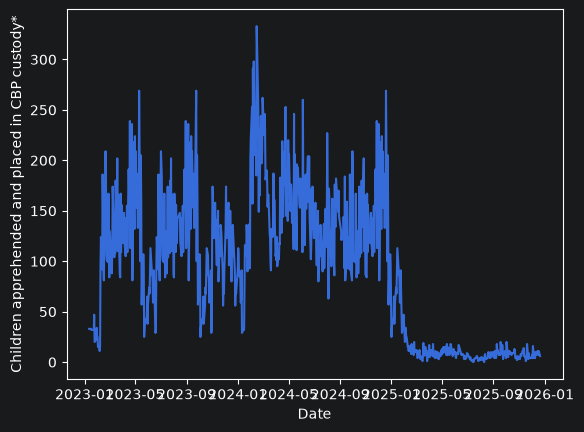

In [216]:
sns.lineplot(data=df_6,x="Date",y="Children apprehended and placed in CBP custody*")